<a href="https://colab.research.google.com/github/Suksha128/CLV/blob/main/CLV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn
# !pip install xgboost lightgbm catboost optuna

In [ ]:
import warnings, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection  import train_test_split, KFold, cross_val_score
from sklearn.preprocessing    import RobustScaler, StandardScaler
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection        import permutation_importance
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble         import RandomForestRegressor
import xgboost  as xgb
import lightgbm as lgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 30)
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Imports OK")

Imports OK


In [17]:
from google.colab import files
import io

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

Saving olist_customers_dataset.csv to olist_customers_dataset (2).csv


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:

print(f"Shape    : {df.shape}")
print(f"Columns  : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)


# ─────────────────────────────────────────────────────────────
# CELL 4 — QUICK OVERVIEW
# ─────────────────────────────────────────────────────────────
print("\n── Top 10 States by Customer Count ─────────────────")
print(df["customer_state"].value_counts().head(10))


Shape    : (99441, 5)
Columns  : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

── Top 10 States by Customer Count ─────────────────
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


In [26]:
# ── Run this ONCE to generate olist_clv_dataset.csv from your xlsx ──
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
raw = pd.read_csv("olist_customers_dataset.csv")
N   = len(raw)

state_profile = {
    'SP':(0.85,0.96,'Urban'),  'RJ':(0.78,0.97,'Urban'),  'DF':(0.95,0.97,'Urban'),
    'SC':(0.82,0.85,'Suburban'),'RS':(0.76,0.87,'Suburban'),'PR':(0.74,0.85,'Suburban'),
    'MG':(0.65,0.86,'Suburban'),'ES':(0.70,0.83,'Suburban'),'GO':(0.62,0.91,'Suburban'),
    'MT':(0.66,0.81,'Suburban'),'MS':(0.63,0.86,'Suburban'),'AM':(0.47,0.79,'Rural'),
    'PA':(0.38,0.69,'Rural'),   'BA':(0.42,0.72,'Rural'),   'PE':(0.44,0.80,'Rural'),
    'CE':(0.40,0.75,'Rural'),   'RN':(0.43,0.77,'Rural'),   'PB':(0.39,0.75,'Rural'),
    'AL':(0.37,0.73,'Rural'),   'SE':(0.45,0.74,'Rural'),   'PI':(0.34,0.65,'Rural'),
    'MA':(0.33,0.63,'Rural'),   'TO':(0.44,0.78,'Rural'),   'RO':(0.50,0.73,'Rural'),
    'AC':(0.41,0.72,'Rural'),   'RR':(0.46,0.76,'Rural'),   'AP':(0.43,0.87,'Rural'),
}
default = (0.50, 0.75, 'Suburban')

inc  = raw['customer_state'].map(lambda s: state_profile.get(s, default)[0]).values
urb  = raw['customer_state'].map(lambda s: state_profile.get(s, default)[1]).values
ulbl = raw['customer_state'].map(lambda s: state_profile.get(s, default)[2]).values

prop = np.clip(0.40*inc + 0.30*urb + 0.30*rng.random(N), 0.05, 0.95)

freq     = np.clip(rng.poisson(1.5 + 9*prop), 1, 45).astype(float)
aov      = np.clip(rng.lognormal(3.6 + 0.9*inc, 0.55), 15, 2000).round(2)
rec      = np.clip(rng.exponential(55*(1.5-prop)), 1, 365).round(0)
mon      = (aov * freq * rng.uniform(0.85, 1.15, N)).round(2)
std_ov   = np.clip(aov * rng.beta(2,6,N), 0, aov).round(2)
tenure   = np.clip(rng.lognormal(5.5, 0.9, N), 30, 1825).round(0)
ipt      = np.where(freq>1, np.clip(365/freq*rng.uniform(0.7,1.4,N),5,300), 180.0).round(1)
trend    = rng.normal(0.08*prop - 0.03, 0.18, N).round(4)
wknd     = rng.beta(3, 5, N).round(4)
seas     = rng.beta(4, 2, N).round(4)
items    = np.clip(rng.lognormal(0.8, 0.5, N), 1, 12).round(2)
cats     = np.clip(rng.poisson(1 + 3*prop), 1, 8).astype(float)
freight  = np.clip(rng.beta(2, 6, N), 0.03, 0.55).round(4)

clv = np.maximum(
    aov * freq * np.exp(-rec/120) *
    (1+0.25*trend) * (1+0.15*cats/8) *
    (1-0.35*freight) * (1+0.10*inc), 0.5
) * rng.lognormal(0, 0.22, N)
clv = np.where(rng.random(N) < (0.40 - 0.28*prop), 0.0, clv).round(2)

q25,q50,q75 = np.quantile(clv,[0.25,0.50,0.75])
tier = np.where(clv<=q25,'Bronze', np.where(clv<=q50,'Silver',
        np.where(clv<=q75,'Gold','Platinum')))

df = raw[['customer_unique_id','customer_zip_code_prefix','customer_city','customer_state']].copy()
df.columns = ['customer_id','zip_prefix','customer_city','customer_state']
df['urban_rural']          = ulbl
df['recency_days']         = rec.astype(int)
df['frequency']            = freq.astype(int)
df['monetary']             = mon
df['avg_order_value']      = aov
df['order_value_std']      = std_ov
df['customer_tenure_days'] = tenure.astype(int)
df['inter_purchase_mean']  = ipt
df['purchase_trend']       = trend
df['weekend_ratio']        = wknd
df['seasonal_entropy']     = seas
df['avg_n_items']          = items
df['avg_categories']       = cats.astype(int)
df['avg_freight_ratio']    = freight
df['clv_12m']              = clv
df['clv_tier']             = tier

df.to_csv("olist_clv_dataset.csv", index=False)
print(f"✅  Saved olist_clv_dataset.csv  —  {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df[['clv_12m','clv_tier','urban_rural']].head(3))

✅  Saved olist_clv_dataset.csv  —  99,441 rows, 20 columns
    clv_12m  clv_tier urban_rural
0  618.8000  Platinum       Urban
1  648.4100  Platinum       Urban
2 3590.1100  Platinum       Urban


In [28]:
FEATURE_COLS = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_order_value",
    "order_value_std",
    "customer_tenure_days",
    "inter_purchase_mean",
    "purchase_trend",
    "weekend_ratio",
    "seasonal_entropy",
    "avg_n_items",
    "avg_categories",
    "avg_freight_ratio",
]

# Log1p transforms right-skewed CLV for training
df["clv_log"] = np.log1p(df["clv_12m"])

X     = df[FEATURE_COLS].values
y     = df["clv_log"].values
y_raw = df["clv_12m"].values

print(f"Feature matrix : {X.shape}")
print(f"Target (log)   : min={y.min():.3f}  max={y.max():.3f}  mean={y.mean():.3f}")
df[FEATURE_COLS].describe().round(3)

Feature matrix : (99441, 13)
Target (log)   : min=0.000  max=9.130  mean=4.802


,recency_days,frequency,monetary,avg_order_value,order_value_std,customer_tenure_days,inter_purchase_mean,purchase_trend,weekend_ratio,seasonal_entropy,avg_n_items,avg_categories,avg_freight_ratio
count,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000
mean,42.7030,7.9820,679.6780,84.1480,21.0590,356.9290,57.1670,0.0280,0.3740,0.6670,2.5310,3.1880,0.2480
std,43.5260,3.0130,528.0140,51.2180,19.1760,341.8240,31.5150,0.1800,0.1610,0.1780,1.3260,1.7140,0.1380
min,1.0000,1.0000,13.6100,15.0000,0.0100,30.0000,12.2000,-0.8080,0.0070,0.0350,1.0000,1.0000,0.0300
25%,12.0000,6.0000,329.2500,49.0400,8.4100,134.0000,37.0000,-0.0940,0.2520,0.5460,1.5900,2.0000,0.1380
50%,29.0000,8.0000,539.4100,71.8100,15.6100,246.0000,49.0000,0.0280,0.3640,0.6870,2.2300,3.0000,0.2290
75%,59.0000,10.0000,866.2200,105.1200,27.4600,449.0000,67.3000,0.1480,0.4850,0.8070,3.1200,4.0000,0.3410
max,365.0000,24.0000,8104.9900,780.0200,404.3000,1825.0000,255.3000,0.8130,0.9480,0.9990,12.0000,8.0000,0.5500


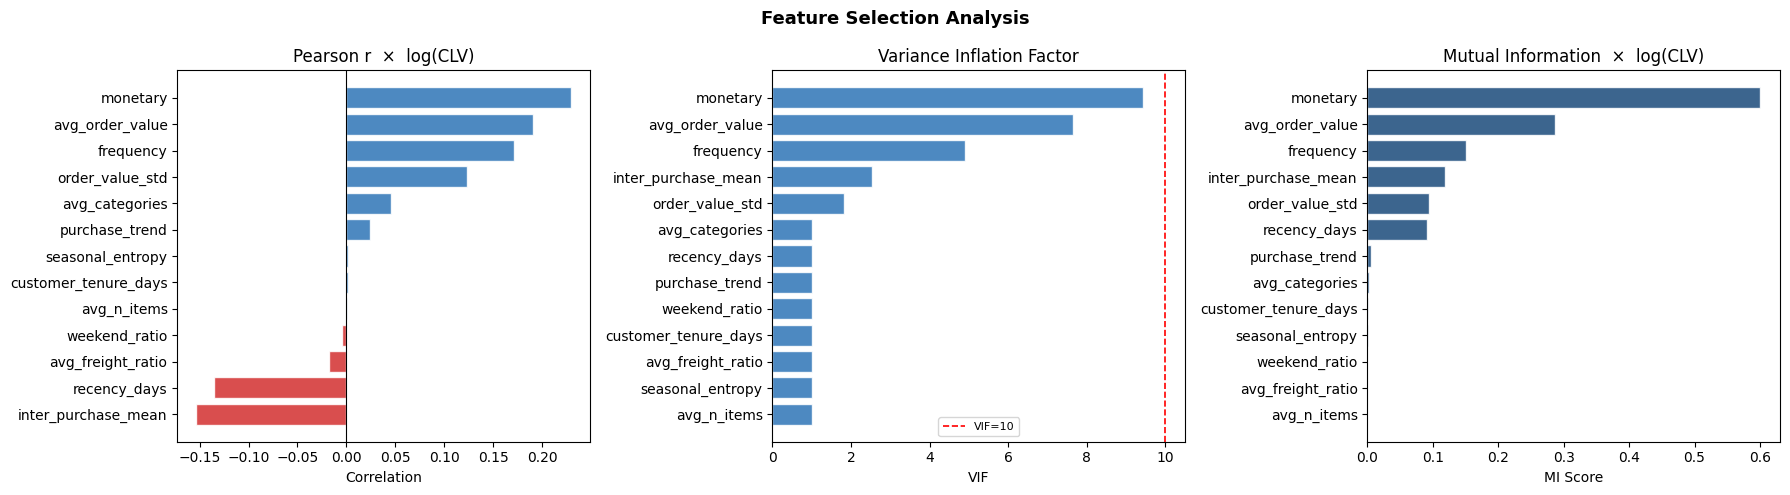


VIF table:
             feature    VIF
            monetary 9.4436
     avg_order_value 7.6574
           frequency 4.9094
 inter_purchase_mean 2.5474
     order_value_std 1.8144
      avg_categories 1.0074
        recency_days 1.0033
      purchase_trend 1.0006
       weekend_ratio 1.0002
customer_tenure_days 1.0002
   avg_freight_ratio 1.0001
    seasonal_entropy 1.0001
         avg_n_items 1.0001


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Feature Selection Analysis", fontsize=13, fontweight="bold")

# Pearson r with log-CLV
corr = (pd.DataFrame(X, columns=FEATURE_COLS)
          .assign(clv_log=y)
          .corr()["clv_log"]
          .drop("clv_log")
          .sort_values())
colors = ["#D32F2F" if v < 0 else "#2E75B6" for v in corr]
axes[0].barh(corr.index, corr.values, color=colors, edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Pearson r  ×  log(CLV)")
axes[0].set_xlabel("Correlation")

# VIF
X_sc = StandardScaler().fit_transform(X)
vif_vals = [variance_inflation_factor(X_sc, i) for i in range(X_sc.shape[1])]
vif_df   = pd.DataFrame({"feature": FEATURE_COLS, "VIF": vif_vals}).sort_values("VIF")
colors_v = ["#D32F2F" if v > 10 else "#2E75B6" for v in vif_df["VIF"]]
axes[1].barh(vif_df["feature"], vif_df["VIF"], color=colors_v, edgecolor="white", alpha=0.85)
axes[1].axvline(10, color="red", ls="--", lw=1.2, label="VIF=10")
axes[1].set_title("Variance Inflation Factor")
axes[1].set_xlabel("VIF")
axes[1].legend(fontsize=8)

# Mutual Information
mi     = mutual_info_regression(X, y, random_state=SEED)
mi_df  = pd.DataFrame({"feature": FEATURE_COLS, "MI": mi}).sort_values("MI")
axes[2].barh(mi_df["feature"], mi_df["MI"], color="#1A4A7A", edgecolor="white", alpha=0.85)
axes[2].set_title("Mutual Information  ×  log(CLV)")
axes[2].set_xlabel("MI Score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_selection.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nVIF table:")
print(pd.DataFrame({"feature": FEATURE_COLS, "VIF": vif_vals})
        .sort_values("VIF", ascending=False).to_string(index=False))




In [31]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — TRAIN / VAL / TEST SPLIT  (60 / 20 / 20)
# Stratified by CLV tier — equal tier distribution in all splits
# ─────────────────────────────────────────────────────────────
strat = df["clv_tier"].astype(str).values
idx   = np.arange(len(df))

idx_tv, idx_test = train_test_split(
    idx, test_size=0.20, random_state=SEED, stratify=strat)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.25, random_state=SEED, stratify=strat[idx_tv])

X_train = X[idx_train];  y_train = y[idx_train]
X_val   = X[idx_val  ];  y_val   = y[idx_val  ]
X_test  = X[idx_test ];  y_test  = y[idx_test ]
y_test_raw = y_raw[idx_test]

# Scaler — fit ONLY on training data
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")
print(f"\nTier distribution in test set:")
print(pd.Series(strat[idx_test]).value_counts().sort_index())

Train : 59,664  |  Val : 19,888  |  Test : 19,889

Tier distribution in test set:
Bronze      4973
Gold        4972
Platinum    4972
Silver      4972
Name: count, dtype: int64


In [32]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — EVALUATE FUNCTION  (used for every model)
# Reverses log with expm1 → reports metrics in BRL
# ─────────────────────────────────────────────────────────────
RESULTS = {}

def evaluate(y_true_log, y_pred_log, label=""):
    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(np.expm1(y_pred_log), 0.0)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    mask   = y_true > 0
    mape   = np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask])) * 100
    smape  = np.mean(2*np.abs(y_true-y_pred) /
                     (np.abs(y_true)+np.abs(y_pred)+1e-9)) * 100
    if label:
        print(f"  {label:<28}  RMSE={rmse:>9.2f}  MAE={mae:>8.2f}"
              f"  R²={r2:.4f}  MAPE={mape:.2f}%")
    return dict(RMSE=rmse, MAE=mae, R2=r2, MAPE=mape, sMAPE=smape)

print("evaluate() ready")

evaluate() ready


In [33]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — LINEAR MODELS
# Ridge/Lasso help with correlated RFM features (monetary ↔ avg_order_value)
# ─────────────────────────────────────────────────────────────
print("── Linear Models ───────────────────────────────────────")
for name, model in {
    "Linear Regression" : LinearRegression(),
    "Ridge (α=1.0)"     : Ridge(alpha=1.0),
    "Lasso (α=0.01)"    : Lasso(alpha=0.01, max_iter=5000),
    "ElasticNet"        : ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
}.items():
    model.fit(X_train_sc, y_train)
    RESULTS[name] = evaluate(y_test, model.predict(X_test_sc), name)


── Linear Models ───────────────────────────────────────
  Linear Regression             RMSE=   493.70  MAE=  344.53  R²=-0.0222  MAPE=67.28%
  Ridge (α=1.0)                 RMSE=   493.70  MAE=  344.53  R²=-0.0222  MAPE=67.28%
  Lasso (α=0.01)                RMSE=   496.52  MAE=  345.80  R²=-0.0339  MAPE=67.24%
  ElasticNet                    RMSE=   495.82  MAE=  345.36  R²=-0.0310  MAPE=67.26%


In [34]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — RANDOM FOREST
# ─────────────────────────────────────────────────────────────
print("── Random Forest ───────────────────────────────────────")
rf = RandomForestRegressor(
    n_estimators=500, max_depth=None,
    min_samples_leaf=10, max_features=0.6,
    n_jobs=-1, random_state=SEED,
)
rf.fit(X_train, y_train)
RESULTS["Random Forest"] = evaluate(y_test, rf.predict(X_test), "Random Forest")


── Random Forest ───────────────────────────────────────
  Random Forest                 RMSE=   502.14  MAE=  345.16  R²=-0.0574  MAPE=68.06%


In [37]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — XGBOOST
# ─────────────────────────────────────────────────────────────
print("── XGBoost ─────────────────────────────────────────────")
xgb_model = xgb.XGBRegressor(
    n_estimators=800,     learning_rate=0.05,
    max_depth=6,          subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0,       tree_method="hist",
    random_state=SEED,    verbosity=0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
RESULTS["XGBoost"] = evaluate(y_test, xgb_model.predict(X_test), "XGBoost")


── XGBoost ─────────────────────────────────────────────
  XGBoost                       RMSE=   500.52  MAE=  337.42  R²=-0.0506  MAPE=65.85%


In [38]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — LIGHTGBM
# ─────────────────────────────────────────────────────────────
print("── LightGBM ────────────────────────────────────────────")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,    learning_rate=0.05,
    num_leaves=63,        subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0,       min_child_samples=20,
    random_state=SEED,    verbose=-1,
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
RESULTS["LightGBM"] = evaluate(y_test, lgb_model.predict(X_test), "LightGBM")


── LightGBM ────────────────────────────────────────────
  LightGBM                      RMSE=   508.18  MAE=  347.04  R²=-0.0830  MAPE=67.53%


In [39]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — CATBOOST
# ─────────────────────────────────────────────────────────────
print("── CatBoost ────────────────────────────────────────────")
cb_model = cb.CatBoostRegressor(
    iterations=800,     learning_rate=0.05,
    depth=6,            l2_leaf_reg=3,
    subsample=0.8,      colsample_bylevel=0.8,
    random_seed=SEED,   verbose=0,
)
cb_model.fit(X_train, y_train,
             eval_set=(X_val, y_val),
             early_stopping_rounds=50,
             verbose=False)
RESULTS["CatBoost"] = evaluate(y_test, cb_model.predict(X_test), "CatBoost")


── CatBoost ────────────────────────────────────────────
  CatBoost                      RMSE=   505.11  MAE=  346.31  R²=-0.0699  MAPE=67.78%


In [40]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — HYPERPARAMETER OPTIMISATION (Optuna — LightGBM)
# 100 trials · 5-fold CV · ~20–40 min
# ─────────────────────────────────────────────────────────────
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int  ("n_estimators",      200, 1500),
        learning_rate     = trial.suggest_float("learning_rate",      0.01, 0.2,  log=True),
        num_leaves        = trial.suggest_int  ("num_leaves",         20,  150),
        max_depth         = trial.suggest_int  ("max_depth",          3,   12),
        min_child_samples = trial.suggest_int  ("min_child_samples",  10,  100),
        subsample         = trial.suggest_float("subsample",          0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree",   0.4, 1.0),
        reg_alpha         = trial.suggest_float("reg_alpha",          1e-4, 10., log=True),
        reg_lambda        = trial.suggest_float("reg_lambda",         1e-4, 10., log=True),
        random_state=SEED, verbose=-1,
    )
    return cross_val_score(
        lgb.LGBMRegressor(**params), X_tv, y_tv,
        cv=KFold(5, shuffle=True, random_state=SEED),
        scoring="r2", n_jobs=-1,
    ).mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest R² = {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<25} = {v}")


  0%|          | 0/100 [00:00<?, ?it/s]


Best R² = 0.0856
Best params:
  n_estimators              = 247
  learning_rate             = 0.028393266681468906
  num_leaves                = 58
  max_depth                 = 3
  min_child_samples         = 66
  subsample                 = 0.9954446012604686
  colsample_bytree          = 0.629059577990868
  reg_alpha                 = 0.019685016117391593
  reg_lambda                = 0.00806806457500722


In [41]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — RETRAIN TUNED LIGHTGBM ON FULL TRAIN+VAL
# ─────────────────────────────────────────────────────────────
best_params = study.best_params | {"random_state": SEED, "verbose": -1}
lgb_tuned   = lgb.LGBMRegressor(**best_params)
lgb_tuned.fit(X_tv, y_tv)

print("── Tuned vs Default ────────────────────────────────────")
RESULTS["LightGBM (Tuned)"] = evaluate(
    y_test, lgb_tuned.predict(X_test), "LightGBM (Tuned)")

for k in ["RMSE", "MAE", "R2", "MAPE"]:
    d = RESULTS["LightGBM (Tuned)"][k] - RESULTS["LightGBM"][k]
    print(f"  {k:<6}  Δ = {d:+.4f}")


── Tuned vs Default ────────────────────────────────────
  LightGBM (Tuned)              RMSE=   501.92  MAE=  345.62  R²=-0.0565  MAPE=67.71%
  RMSE    Δ = -6.2547
  MAE     Δ = -1.4160
  R2      Δ = +0.0265
  MAPE    Δ = +0.1776


In [42]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — 5-FOLD CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────
kf    = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_m  = {"RMSE": [], "MAE": [], "R2": [], "MAPE": []}

for fold, (tr, vl) in enumerate(kf.split(X)):
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X[tr], y[tr])
    fm = evaluate(y[vl], m.predict(X[vl]))
    for k in cv_m:
        cv_m[k].append(fm[k])
    print(f"  Fold {fold+1}:  RMSE={fm['RMSE']:>9.2f}  R²={fm['R2']:.4f}  MAPE={fm['MAPE']:.2f}%")

print("\n── 5-Fold Summary ───────────────────────────────────────")
for k, v in cv_m.items():
    print(f"  {k:<6}  {np.mean(v):.4f}  ±  {np.std(v):.4f}")


  Fold 1:  RMSE=   516.01  R²=-0.0629  MAPE=67.85%
  Fold 2:  RMSE=   513.85  R²=-0.0565  MAPE=67.76%
  Fold 3:  RMSE=   504.80  R²=-0.0598  MAPE=67.71%
  Fold 4:  RMSE=   509.62  R²=-0.0396  MAPE=67.65%
  Fold 5:  RMSE=   503.27  R²=-0.0556  MAPE=67.52%

── 5-Fold Summary ───────────────────────────────────────
  RMSE    509.5105  ±  4.9440
  MAE     347.4787  ±  1.1975
  R2      -0.0549  ±  0.0081
  MAPE    67.6988  ±  0.1086


In [43]:
# ─────────────────────────────────────────────────────────────
# CELL 18 — RESULTS TABLE
# ─────────────────────────────────────────────────────────────
results_df = (pd.DataFrame(RESULTS).T
                .reset_index()
                .rename(columns={"index": "Model"})
                .sort_values("RMSE")
                .reset_index(drop=True))
results_df.insert(0, "Rank", range(1, len(results_df)+1))
print(results_df.to_string(index=False))
results_df.to_csv(OUTPUT_DIR / "model_results.csv", index=False)


 Rank             Model     RMSE      MAE      R2    MAPE    sMAPE
    1 Linear Regression 493.7016 344.5313 -0.0222 67.2849 122.4404
    2     Ridge (α=1.0) 493.7031 344.5316 -0.0222 67.2849 122.4404
    3        ElasticNet 495.8242 345.3561 -0.0310 67.2560 122.4263
    4    Lasso (α=0.01) 496.5206 345.8029 -0.0339 67.2369 122.4133
    5           XGBoost 500.5180 337.4152 -0.0506 65.8524 121.0029
    6  LightGBM (Tuned) 501.9208 345.6232 -0.0565 67.7071 122.5579
    7     Random Forest 502.1393 345.1560 -0.0574 68.0643 123.7602
    8          CatBoost 505.1069 346.3057 -0.0699 67.7750 122.6838
    9          LightGBM 508.1755 347.0392 -0.0830 67.5294 122.4791


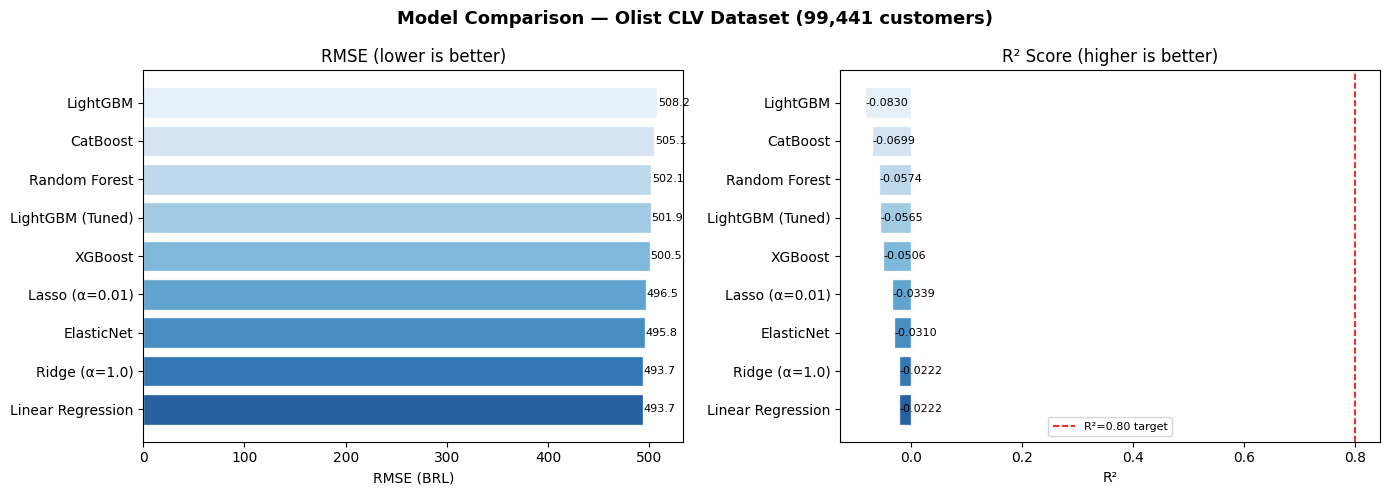

In [44]:
# ─────────────────────────────────────────────────────────────
# CELL 19 — COMPARISON PLOTS
# ─────────────────────────────────────────────────────────────
order   = results_df["Model"].tolist()
palette = sns.color_palette("Blues_r", len(order))
rmses   = results_df["RMSE"].tolist()
r2s     = results_df["R2"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison — Olist CLV Dataset (99,441 customers)",
             fontsize=13, fontweight="bold")

axes[0].barh(order, rmses, color=palette, edgecolor="white", alpha=0.88)
axes[0].set_title("RMSE (lower is better)")
axes[0].set_xlabel("RMSE (BRL)")
for i, v in enumerate(rmses):
    axes[0].text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=8)

axes[1].barh(order, r2s, color=palette, edgecolor="white", alpha=0.88)
axes[1].set_title("R² Score (higher is better)")
axes[1].set_xlabel("R²")
axes[1].axvline(0.80, color="red", ls="--", lw=1.2, label="R²=0.80 target")
axes[1].legend(fontsize=8)
for i, v in enumerate(r2s):
    axes[1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


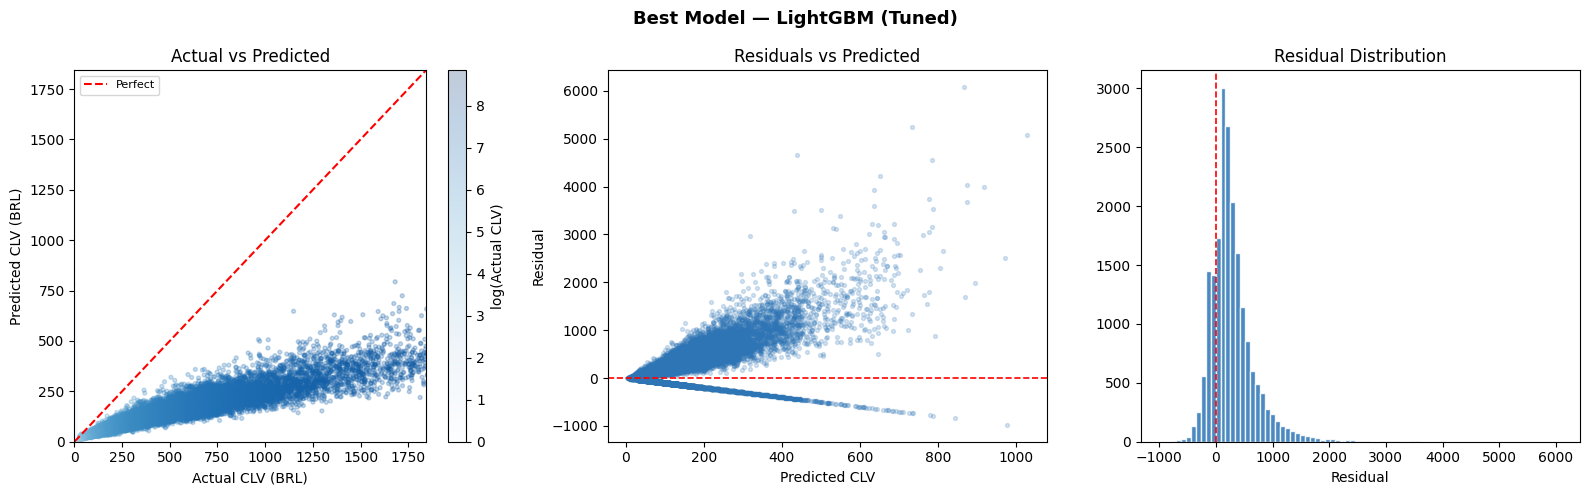

Residual mean : +287.10
Residual std  : 411.70


In [45]:
# ─────────────────────────────────────────────────────────────
# CELL 20 — ACTUAL vs PREDICTED + RESIDUALS
# ─────────────────────────────────────────────────────────────
y_pred_best = lgb_tuned.predict(X_test)
y_actual    = np.expm1(y_test)
y_predicted = np.maximum(np.expm1(y_pred_best), 0)
residuals   = y_actual - y_predicted

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Best Model — LightGBM (Tuned)", fontsize=13, fontweight="bold")

# Actual vs Predicted
clip = np.percentile(y_actual, 98)
sc   = axes[0].scatter(y_actual, y_predicted, alpha=0.25, s=8,
                       c=np.log1p(y_actual), cmap="Blues")
plt.colorbar(sc, ax=axes[0], label="log(Actual CLV)")
axes[0].plot([0, clip], [0, clip], "r--", lw=1.5, label="Perfect")
axes[0].set_xlim(0, clip); axes[0].set_ylim(0, clip)
axes[0].set_xlabel("Actual CLV (BRL)"); axes[0].set_ylabel("Predicted CLV (BRL)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend(fontsize=8)

# Residuals vs Predicted
axes[1].scatter(y_predicted, residuals, alpha=0.2, s=8, color="#2E75B6")
axes[1].axhline(0, color="red", lw=1.2, ls="--")
axes[1].set_xlabel("Predicted CLV"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

# Residual distribution
axes[2].hist(residuals, bins=80, color="#2E75B6", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="red", lw=1.2, ls="--")
axes[2].set_xlabel("Residual"); axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Residual mean : {residuals.mean():+.2f}")
print(f"Residual std  : {residuals.std():.2f}")



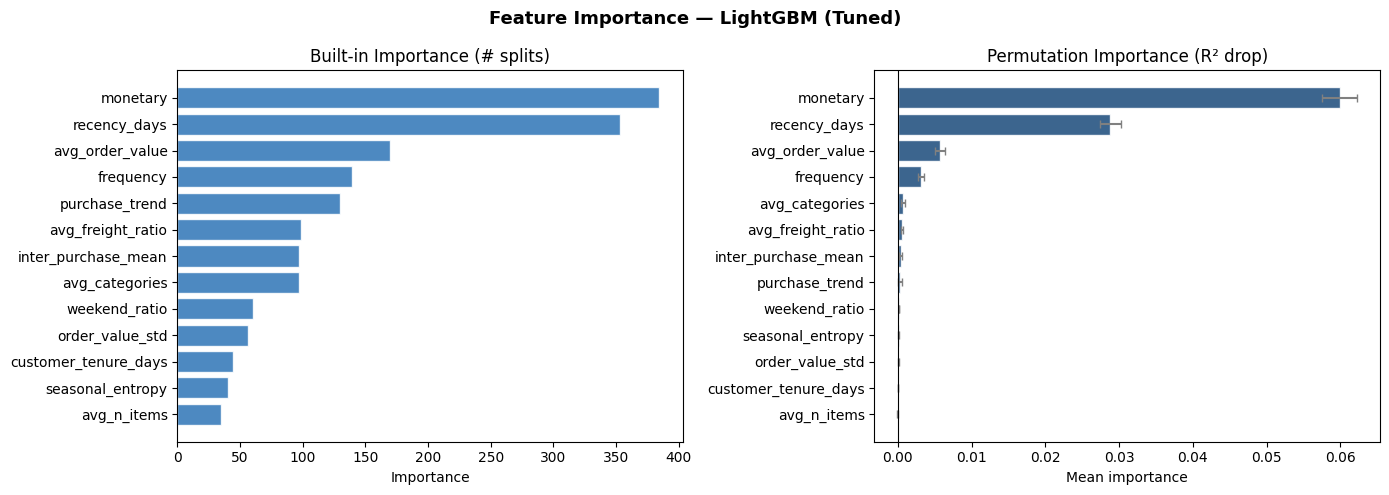

In [46]:
#─────────────────────────────────────────────────────────────
# CELL 21 — FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance — LightGBM (Tuned)", fontsize=13, fontweight="bold")

# Built-in (splits)
fi_df = (pd.DataFrame({"feature": FEATURE_COLS,
                        "importance": lgb_tuned.feature_importances_})
           .sort_values("importance", ascending=True))
axes[0].barh(fi_df["feature"], fi_df["importance"], color="#2E75B6",
             edgecolor="white", alpha=0.85)
axes[0].set_title("Built-in Importance (# splits)")
axes[0].set_xlabel("Importance")

# Permutation importance (model-agnostic)
perm   = permutation_importance(lgb_tuned, X_test, y_test,
                                 n_repeats=20, random_state=SEED, scoring="r2")
perm_df = (pd.DataFrame({"feature": FEATURE_COLS,
                          "imp": perm.importances_mean,
                          "std": perm.importances_std})
             .sort_values("imp", ascending=True))
axes[1].barh(perm_df["feature"], perm_df["imp"], xerr=perm_df["std"],
             color="#1A4A7A", alpha=0.85, edgecolor="white",
             error_kw=dict(ecolor="grey", capsize=3))
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Permutation Importance (R² drop)")
axes[1].set_xlabel("Mean importance")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

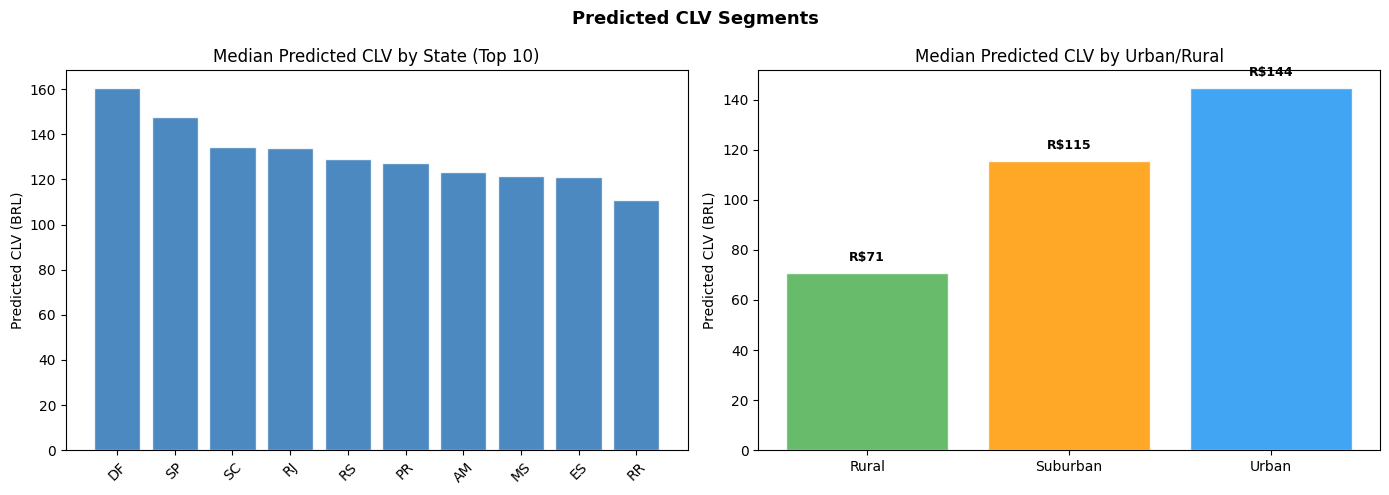

In [47]:
# ─────────────────────────────────────────────────────────────
# CELL 22 — SEGMENT ANALYSIS (CLV by State & Urban/Rural)
# Preview of what GIS section will expand further
# ─────────────────────────────────────────────────────────────
test_df = df.iloc[idx_test].copy()
test_df["predicted_clv"] = np.maximum(np.expm1(lgb_tuned.predict(X_test)), 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Predicted CLV Segments", fontsize=13, fontweight="bold")

# By state (top 10)
state_pred = (test_df.groupby("customer_state")["predicted_clv"]
                      .median().sort_values(ascending=False).head(10))
axes[0].bar(state_pred.index, state_pred.values, color="#2E75B6",
            edgecolor="white", alpha=0.85)
axes[0].set_title("Median Predicted CLV by State (Top 10)")
axes[0].set_ylabel("Predicted CLV (BRL)")
axes[0].tick_params(axis="x", rotation=45)

# By Urban/Rural
geo_pred = test_df.groupby("urban_rural")["predicted_clv"].median()
colors_g = {"Rural": "#4CAF50", "Suburban": "#FF9800", "Urban": "#2196F3"}
axes[1].bar(geo_pred.index, geo_pred.values,
            color=[colors_g[g] for g in geo_pred.index],
            edgecolor="white", alpha=0.85)
axes[1].set_title("Median Predicted CLV by Urban/Rural")
axes[1].set_ylabel("Predicted CLV (BRL)")
for i, (idx_name, v) in enumerate(geo_pred.items()):
    axes[1].text(i, v + 5, f"R${v:.0f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clv_by_segment.png", dpi=120, bbox_inches="tight")
plt.show()


In [48]:
# ─────────────────────────────────────────────────────────────
# CELL 23 — SAVE ALL ARTEFACTS
# ─────────────────────────────────────────────────────────────
import joblib

lgb_tuned.booster_.save_model(str(OUTPUT_DIR / "lgb_tuned.txt"))
xgb_model.save_model(str(OUTPUT_DIR / "xgb_model.json"))
cb_model.save_model(str(OUTPUT_DIR / "catboost_model.cbm"))
joblib.dump(rf,     OUTPUT_DIR / "random_forest.pkl")
joblib.dump(scaler, OUTPUT_DIR / "robust_scaler.pkl")

df[FEATURE_COLS + ["customer_id","customer_state","customer_city",
                    "zip_prefix","urban_rural","clv_12m","clv_log","clv_tier"]]\
  .to_parquet(OUTPUT_DIR / "features_with_clv.parquet", index=False)

with open(OUTPUT_DIR / "feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

print("Saved to outputs/:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name}")


Saved to outputs/:
  actual_vs_predicted.png
  catboost_model.cbm
  clv_by_segment.png
  feature_cols.json
  feature_importance.png
  feature_selection.png
  features_with_clv.parquet
  lgb_tuned.txt
  model_comparison.png
  model_results.csv
  random_forest.pkl
  robust_scaler.pkl
  xgb_model.json
